In [1]:
import pandas as pd
df=pd.read_csv("processed_logs.csv")
df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )

In [2]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df["hour"] = df["timestamp"].dt.hour
df["hour"]=(df["timestamp"].dt.hour)
df[["timestamp","hour"]].head()

,timestamp,hour
0,2008-11-09 20:36:15,20
1,2008-11-09 20:38:07,20
2,2008-11-09 20:40:05,20
3,2008-11-09 20:40:15,20
4,2008-11-09 20:41:06,20


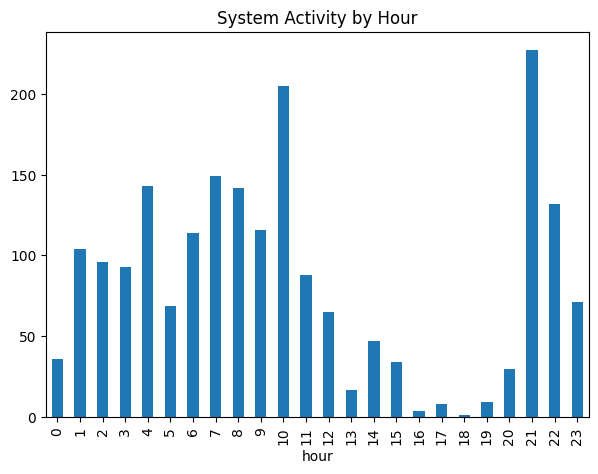

In [3]:
import matplotlib.pyplot as plt
plt.title("System Activity by Hour")
activity=(df.groupby("hour").size())
activity.plot(kind="bar",figsize=(7,5))
plt.show()

In [5]:
event_diversity=(df["eventid"].nunique())
warn_count=(df["level"]=="WARN").sum()
health=(100-warn_count*0.1-event_diversity*0.5)
health=max(0,health)
print(f"Health Score: {health:.2f}%")

Health Score: 85.00%
